In [65]:
#Lab 07
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage.feature import hog
from skimage import exposure


# FUNCTIONS ----------------------------------------------------------------------------------------
# Both LoadImage and GetSobelFeatures are from assignment 1: modified a bit
def LoadImage(path, size=(256, 256)):
    img = cv2.imread(path)
    img = cv2.resize(img, size)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img


def plot_images_grid(images, titles, cols=4, figsize=(12,6), heatmap=False):
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=figsize)

    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(rows, cols, i+1)
        plt.imshow(img, cmap='viridis' if heatmap else 'gray')
        plt.title(title)
        plt.axis("off")
        if heatmap:
            plt.colorbar()
    plt.tight_layout()
    plt.show()

def otsu_threshold(img):
    best_threshold = 0
    best_variance = float('inf')

    pixels = img.ravel()
    total_pixels = len(pixels)

    for t in range(0,256):
        class0 = pixels[pixels < t]
        class1 = pixels[pixels >= t]

        w0 = len(class0) / total_pixels
        w1 = len(class1) / total_pixels

        var0 = np.var(class0) if len(class0) > 0 else 0
        var1 = np.var(class1) if len(class1) > 0 else 0

        intra_class_variance = w0 * var0 + w1 * var1

        if intra_class_variance < best_variance:
            best_variance = intra_class_variance
            best_threshold = t
    return best_threshold

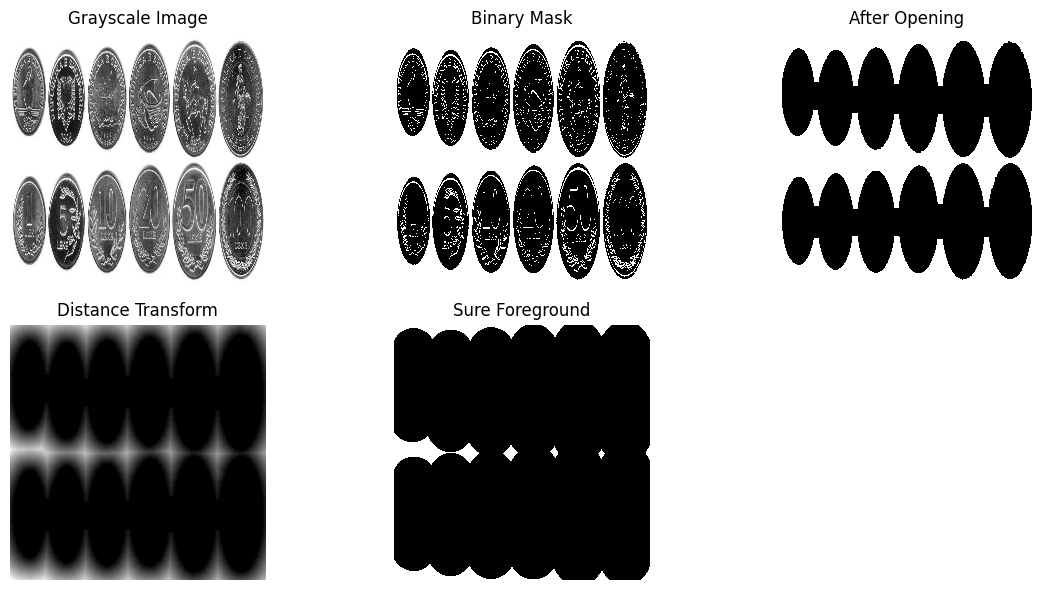

In [66]:
img = LoadImage('12_coins.jpg')
threshold = otsu_threshold(img)

binary_mask = np.zeros_like(img)
binary_mask[img >= threshold] = 255

# --- MORPHOLOGICAL OPENING (remove noise) ---
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel, iterations=2)

# --- DISTANCE TRANSFORM ---
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

# --- THRESHOLD DISTANCE TRANSFORM (sure foreground) ---
max_dist = dist_transform.max()
_, sure_fg = cv2.threshold(dist_transform, 0.5 * max_dist, 255, 0)

# Convert to uint8 for visualization / later use
sure_fg = np.uint8(sure_fg)

# --- VISUALIZATION ---
plot_images_grid(
    [img, binary_mask, opening, dist_transform, sure_fg],
    ['Grayscale Image', 'Binary Mask', 'After Opening', 'Distance Transform', 'Sure Foreground'],
    cols=3,
    heatmap=False
)




Number of detected objects: 12


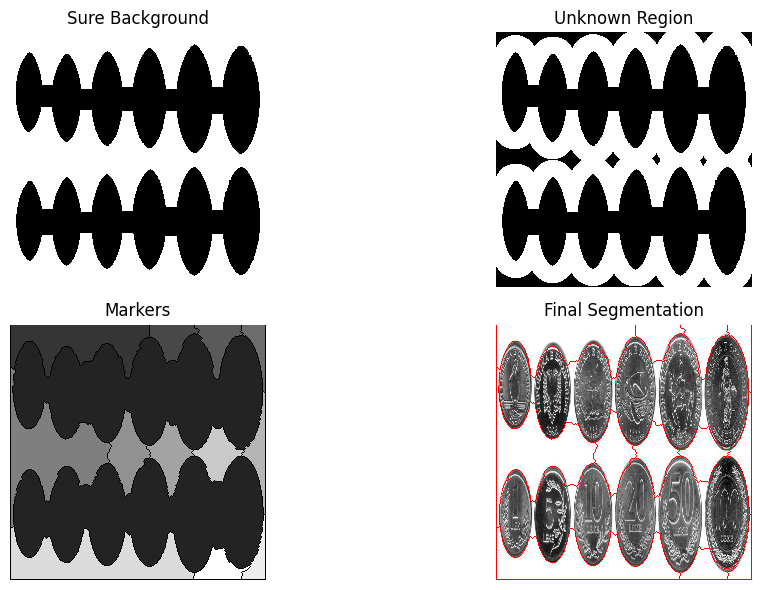

In [67]:
# --- SURE BACKGROUND (dilation) ---
kernel = np.ones((3,3), np.uint8)
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# --- UNKNOWN REGION ---
unknown = cv2.subtract(sure_bg, sure_fg)

# --- CONNECTED COMPONENTS (markers) ---
num_labels, markers = cv2.connectedComponents(sure_fg)

# Increment markers so background is not 0 but 1
markers = markers + 1

# Mark unknown regions as 0
markers[unknown == 255] = 0

# --- WATERSHED ---
# Need a 3-channel image
img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

markers = cv2.watershed(img_color, markers)

# --- OVERLAY BOUNDARIES ---
result = img_color.copy()
result[markers == -1] = [255, 0, 0]  # Red boundaries

# --- COUNT OBJECTS ---
# Subtract 1 because background label = 1
num_objects = num_labels - 1

print("Number of detected objects:", num_objects)

# --- VISUALIZATION ---
plot_images_grid(
    [sure_bg, unknown, markers, result],
    ['Sure Background', 'Unknown Region', 'Markers', 'Final Segmentation'],
    cols=2
)

Threshold 0.3: Objects = 8
Threshold 0.5: Objects = 12
Threshold 0.7: Objects = 14


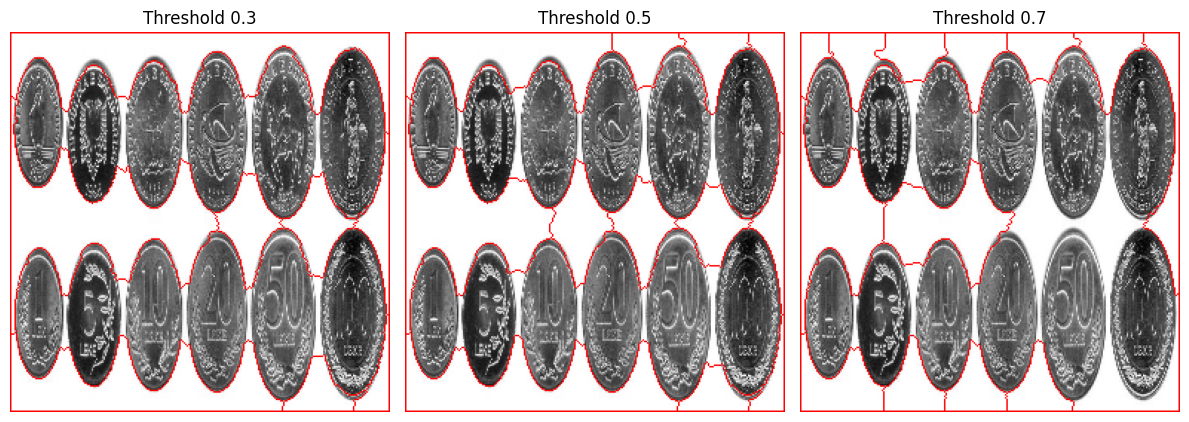

In [68]:
threshold_factors = [0.3, 0.5, 0.7]
results = []
titles = []

for factor in threshold_factors:
    _, sure_fg_var = cv2.threshold(dist_transform, factor * dist_transform.max(), 255, 0)
    sure_fg_var = np.uint8(sure_fg_var)

    # Background
    sure_bg_var = cv2.dilate(opening, kernel, iterations=3)

    # Unknown
    unknown_var = cv2.subtract(sure_bg_var, sure_fg_var)

    # Markers
    num_labels_var, markers_var = cv2.connectedComponents(sure_fg_var)
    markers_var = markers_var + 1
    markers_var[unknown_var == 255] = 0

    # Watershed
    img_color_var = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    markers_var = cv2.watershed(img_color_var, markers_var)

    # Overlay
    result_var = img_color_var.copy()
    result_var[markers_var == -1] = [255, 0, 0]

    print(f"Threshold {factor}: Objects = {num_labels_var - 1}")

    results.append(result_var)
    titles.append(f"Threshold {factor}")

plot_images_grid(results, titles, cols=3)

- 1. Why use “sure foreground” markers instead of all foreground pixels?

Sure foreground markers represent distinct object centres, ensuring one seed per object.
If all foreground pixels are used, the image becomes a single connected region, and watershed cannot separate touching objects, leading to under-segmentation.

- 2. How can over-segmentation be reduced?

Over-segmentation is caused by noise and excessive local minima. It can be reduced by:

Applying Gaussian smoothing to remove noise
Using morphological opening/closing to clean regions
Choosing an appropriate distance transform threshold
Removing small connected components (noise markers)

- 3. Why does the distance transform peak at object centres?

The distance transform measures the distance to the nearest background pixel.
Object centres are farthest from boundaries, so they have the maximum distance values, making them ideal locations for markers.